# Task 2.1: Dataset Selection and Setup
## Paper: Clustering Time Series Using Unsupervised-Shapelets
**Authors**: Jesin Zakaria, Abdullah Mueen, Eamonn J. Keogh — ICDM 2012

## Hyperparameters and Configuration

In [1]:
# =============================================================
# All hyperparameters defined in one place
# =============================================================
import numpy as np

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Dataset parameters
N_CLASSES = 3            # Number of time series classes
N_PER_CLASS = 50         # Number of time series per class
N_TOTAL = N_CLASSES * N_PER_CLASS  # 150 total
TS_LENGTH = 128          # Length of each time series
MOTIF_LENGTH = 20        # Length of the embedded discriminative motif
NOISE_STD = 0.5          # Standard deviation of additive Gaussian noise

print(f'Random Seed: {RANDOM_SEED}')
print(f'Total time series: {N_TOTAL} ({N_PER_CLASS} per class × {N_CLASSES} classes)')
print(f'Time series length: {TS_LENGTH}')
print(f'Motif length: {MOTIF_LENGTH}')
print(f'Noise std: {NOISE_STD}')

Random Seed: 42
Total time series: 150 (50 per class × 3 classes)
Time series length: 128
Motif length: 20
Noise std: 0.5


## Dataset Justification

We use a **synthetic time series dataset** with 150 samples (50 per class) of length 128. Each class contains a distinct short local motif embedded at a random position within a noisy background:

- **Class 0**: Sine-wave bump (one cycle of sin)
- **Class 1**: Triangular spike (rise then fall)
- **Class 2**: Rectangular pulse (step up, hold, step down)

This dataset is a **reasonable testbed** for the u-shapelet method because the discriminative information is entirely local — each class is defined by a unique short pattern, which is precisely what u-shapelets are designed to discover. The random-walk background and Gaussian noise simulate realistic conditions where the majority of the time series is non-informative.

**Limitations compared to the original paper's datasets**: The UCR Archive datasets (CBF, Trace, FaceFour, etc.) used in the paper contain real-world patterns with more complex morphologies, varying levels of inter-class similarity, and potential phase shifts. Our toy dataset has cleaner, more controlled motifs, making the clustering task comparatively easier. This means our Rand Index may be higher than what the paper reports on harder datasets.

## Dataset Generation

In [2]:
import matplotlib.pyplot as plt
import os

def generate_motif(class_id, length):
    """Generate a distinct motif pattern for each class."""
    t = np.linspace(0, 1, length)
    if class_id == 0:
        # Sine-wave bump
        return 2.0 * np.sin(2 * np.pi * t)
    elif class_id == 1:
        # Triangular spike
        return 2.0 * np.where(t < 0.5, 2 * t, 2 * (1 - t))
    elif class_id == 2:
        # Rectangular pulse
        return 2.0 * np.where((t > 0.2) & (t < 0.8), 1.0, 0.0)
    return np.zeros(length)

def generate_dataset(n_classes, n_per_class, ts_length, motif_length, noise_std, seed):
    """Generate synthetic time series dataset with embedded motifs."""
    np.random.seed(seed)
    data = []
    labels = []
    for c in range(n_classes):
        motif = generate_motif(c, motif_length)
        for _ in range(n_per_class):
            # Random-walk background
            ts = np.cumsum(np.random.randn(ts_length) * 0.1)
            # Embed motif at a random position
            pos = np.random.randint(0, ts_length - motif_length + 1)
            ts[pos:pos + motif_length] += motif
            # Add noise
            ts += np.random.randn(ts_length) * noise_std
            data.append(ts)
            labels.append(c)
    return np.array(data), np.array(labels)

# Generate the dataset
data, labels = generate_dataset(N_CLASSES, N_PER_CLASS, TS_LENGTH, MOTIF_LENGTH, NOISE_STD, RANDOM_SEED)
print(f'Data shape: {data.shape}')
print(f'Labels shape: {labels.shape}')
print(f'Class distribution: {np.bincount(labels)}')

Data shape: (150, 128)
Labels shape: (150,)
Class distribution: [50 50 50]


**Explanation**: This code generates 150 time series (50 per class). Each series has a random-walk background, a class-specific motif of length 20 embedded at a random position, and additive Gaussian noise. This design ensures the discriminative information is purely local, matching the u-shapelet assumption.

## Preprocessing: Z-Normalisation

In [3]:
def z_normalize(ts):
    """Z-normalize a time series to zero mean and unit variance."""
    mean = np.mean(ts)
    std = np.std(ts)
    if std == 0:
        return ts - mean
    return (ts - mean) / std

# Z-normalize all time series
data_norm = np.array([z_normalize(ts) for ts in data])
print(f'After z-normalization — mean of first TS: {data_norm[0].mean():.6f}, std: {data_norm[0].std():.6f}')

After z-normalization — mean of first TS: -0.000000, std: 1.000000


**Explanation**: Z-normalisation (zero mean, unit standard deviation) is a standard preprocessing step in time series analysis. The paper uses normalised Euclidean distance internally (Section III-A), so normalising the data ensures consistent distance computation. This step is referenced in the sdist computation where distances are length-normalised.

## Visualisation of Sample Time Series

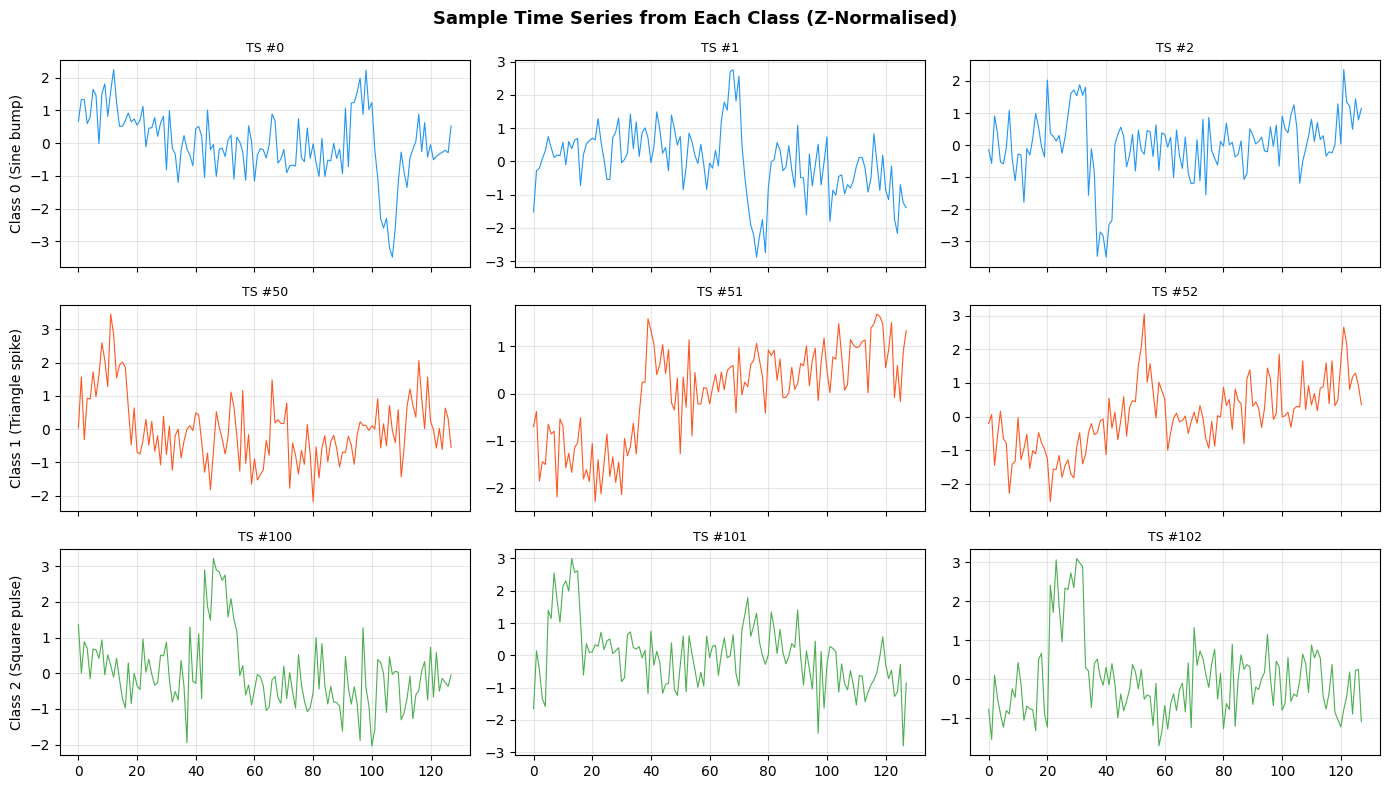

Saved: results/sample_time_series.png


In [4]:
fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharex=True)
class_names = ['Class 0 (Sine bump)', 'Class 1 (Triangle spike)', 'Class 2 (Square pulse)']

for i in range(3):
    class_indices = np.where(labels == i)[0]
    for j in range(3):
        idx = class_indices[j]
        axes[i][j].plot(data_norm[idx], linewidth=0.8, color=['#2196F3', '#FF5722', '#4CAF50'][i])
        if j == 0:
            axes[i][j].set_ylabel(class_names[i], fontsize=10)
        axes[i][j].set_title(f'TS #{idx}', fontsize=9)
        axes[i][j].grid(True, alpha=0.3)

plt.suptitle('Sample Time Series from Each Class (Z-Normalised)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/sample_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/sample_time_series.png')

## Visualisation of the Three Motifs

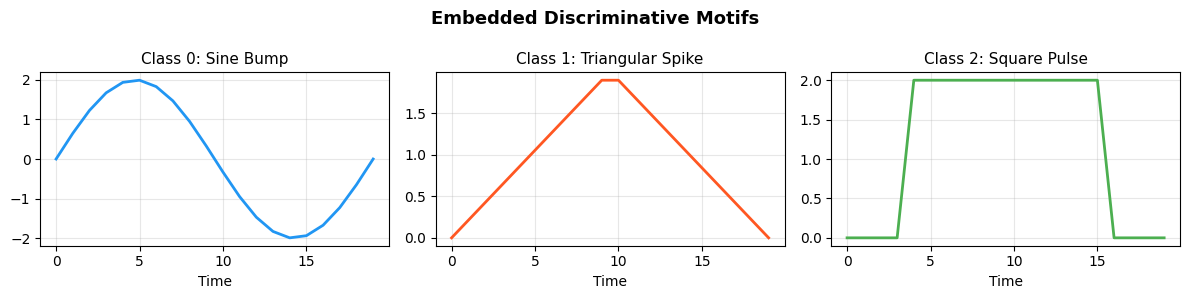

Saved: results/motif_patterns.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
motif_names = ['Sine Bump', 'Triangular Spike', 'Square Pulse']
colors = ['#2196F3', '#FF5722', '#4CAF50']
for i in range(3):
    motif = generate_motif(i, MOTIF_LENGTH)
    axes[i].plot(motif, linewidth=2, color=colors[i])
    axes[i].set_title(f'Class {i}: {motif_names[i]}', fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('Time')

plt.suptitle('Embedded Discriminative Motifs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/motif_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/motif_patterns.png')

## Save Dataset

In [6]:
# Save for use in other notebooks
np.save('data/synthetic_ts_data.npy', data_norm)
np.save('data/synthetic_ts_labels.npy', labels)
print('Dataset saved to data/synthetic_ts_data.npy and data/synthetic_ts_labels.npy')

Dataset saved to data/synthetic_ts_data.npy and data/synthetic_ts_labels.npy
